# Árbol de Decisión - Predicción de Satisfacción de Clientes

---

**Autor:** Borja Mora Méndez
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)
**Categoría:** Machine Learning · Supervisado · Clasificación · Árbol de Decisión

---

### Objetivo

Entrenar un **Árbol de Decisión** para predecir la satisfacción de clientes de un gimnasio urbano, encontrar la profundidad óptima mediante validación cruzada, visualizar las reglas del modelo y traducirlas en decisiones de negocio concretas.

### Contexto de negocio

**El cliente:** cadena de gimnasios urbanos con múltiples sedes.

**El problema:** la dirección necesita identificar clientes insatisfechos antes de que se den de baja. Las encuestas son lentas, caras y llegan tarde.


## 1️. Setup: librerías y configuración visual

In [ ]:
# Librerías base
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Preprocesamiento
from sklearn.model_selection import train_test_split, cross_val_score

# Modelos
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

# Métricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)

# Estilo visual — sistema de color validado (consejo UX/UI Data)
BACKGROUND   = '#fbfbfb'
PURPLE       = '#7a7bff'   # único color de énfasis (1 por gráfico)
PURPLE_LIGHT = '#9b9cff'   # EDA de una sola serie (histogramas) -- PURPLE fuerte queda solo para el enfasis
POSITIVE     = '#6b8158'   # exclusivo signo positivo
NEGATIVE     = '#c34031'   # exclusivo signo negativo
NEUTRAL_BAR  = '#d9d9d9'   # barras/áreas de contexto (siempre con etiqueta de valor)
NEUTRAL_LINE = '#8f8c9e'   # líneas de contexto (más contraste que NEUTRAL_BAR)
CONTEXT_LINES = [NEUTRAL_LINE, '#a89a8a', '#7d94a8']   # gama fija para 2+ lineas de contexto en un mismo grafico
INK          = '#111111'
MUTED        = '#707070'

# Alias de compatibilidad con el resto del notebook
GREEN, RED, GRAY = POSITIVE, NEGATIVE, NEUTRAL_BAR

DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "borja_diverging", ["#c34031", "#e0a89f", "#f0ede8", "#b7c2a9", "#6b8158"]
)
SEQUENTIAL_GREEN = LinearSegmentedColormap.from_list(
    "borja_sequential", [BACKGROUND, POSITIVE]
)

def color_annotations(ax, values, threshold, dark="#ffffff", light=INK):
    """Recolorea el texto de un heatmap celda a celda según su magnitud."""
    for text, value in zip(ax.texts, np.asarray(values).flatten()):
        text.set_color(dark if abs(value) >= threshold else light)

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 100,
    'figure.facecolor': BACKGROUND,
    'axes.facecolor': BACKGROUND,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': MUTED,
    'axes.labelcolor': INK,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.titlecolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
    'font.family': 'sans-serif',
    'font.size': 10,
    'grid.color': '#f0f0f0',
    'grid.linewidth': 0.5,
})

## 2. Carga de datos

In [17]:
data = pd.read_excel("gym_clientes.xlsx")
print(f"Registros: {data.shape[0]} | Columnas: {data.shape[1]}")
data.head()

Registros: 300 | Columnas: 7


,ID_Cliente,Antiguedad_Meses,Asistencias_Mes,Horas_Pico_Mes,Gasto_Mensual_Extra,Satisfecho,Abandono
0,1,29,1,8.673509,64.161055,0,1
1,2,15,1,4.396600,32.554177,0,0
2,3,8,22,22.313433,85.092643,1,0
3,4,21,21,20.598791,120.709423,1,0
4,5,19,18,18.783644,103.148141,1,0


## 3. EDA: Análisis Exploratorio de datos

In [18]:
data.describe().round(2)

,ID_Cliente,Antiguedad_Meses,Asistencias_Mes,Horas_Pico_Mes,Gasto_Mensual_Extra,Satisfecho,Abandono
count,300.00,300.00,300.00,300.00,300.00,300.00,300.00
mean,150.50,18.88,12.16,14.67,81.69,0.48,0.16
std,86.75,10.60,7.27,6.09,30.47,0.50,0.37
min,1.00,1.00,0.00,1.41,10.00,0.00,0.00
25%,75.75,9.00,6.00,9.65,61.25,0.00,0.00
50%,150.50,20.00,12.00,15.07,82.24,0.00,0.00
75%,225.25,28.00,18.25,19.75,104.11,1.00,0.00
max,300.00,35.00,24.00,24.00,145.91,1.00,1.00


In [19]:
# Comprobar nulos y tipos

print('TIPOS DE DATOS Y VALORES NULOS')
print('─' * 70)
info = pd.DataFrame({
    'Tipo': data.dtypes,
    'Nulos': data.isnull().sum(),
    '% Nulos': (data.isnull().sum() / len(data) * 100).round(2),
    'Únicos': data.nunique()
})
info

TIPOS DE DATOS Y VALORES NULOS
──────────────────────────────────────────────────────────────────────


,Tipo,Nulos,% Nulos,Únicos
ID_Cliente,int64,0,0.0,300
Antiguedad_Meses,int64,0,0.0,35
Asistencias_Mes,int64,0,0.0,25
Horas_Pico_Mes,float64,0,0.0,281
Gasto_Mensual_Extra,float64,0,0.0,300
Satisfecho,int64,0,0.0,2
Abandono,int64,0,0.0,2


#### Exploración de la variable Target (Satisfecho)

In [20]:
sat_rate = data["Satisfecho"].value_counts(normalize=True)
print("Distribución del target:")
print(f"  No Satisfecho (0): {sat_rate[0]:.1%}")
print(f"  Satisfecho (1):    {sat_rate[1]:.1%}")
print("\nClases equilibradas (52/48) — accuracy: métrica fiable sin ajustes.")

Distribución del target:
  No Satisfecho (0): 52.0%
  Satisfecho (1):    48.0%

Clases equilibradas (52/48) — accuracy: métrica fiable sin ajustes.


In [ ]:
# Distribuciones de cada variable

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Distribuciones de las variables', 
             fontsize=14, 
             fontweight='bold', 
             color=INK, 
             y=1.00)

variables = ["Antiguedad_Meses", "Asistencias_Mes", "Horas_Pico_Mes", "Gasto_Mensual_Extra"]
for ax, var in zip(axes.flat, variables):
    ax.hist(data[var], bins=20, color=PURPLE_LIGHT, edgecolor='white', alpha=0.85)
    ax.axvline(data[var].mean(), color=INK, linestyle='--', linewidth=1.5, label=f'Media: {data[var].mean():.1f}')
    ax.axvline(data[var].median(), color=NEUTRAL_LINE, linestyle='--', linewidth=1.5, label=f'Mediana: {data[var].median():.1f}')
    ax.set_title(var, color=INK)
    ax.legend(fontsize=9, frameon=False)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Matriz de correlación

cols_num = ["Antiguedad_Meses", "Asistencias_Mes", "Horas_Pico_Mes", "Gasto_Mensual_Extra"]

# Matriz de correlación
corr = data[cols_num].corr()

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".4f",
    cmap=DIVERGING_CMAP,
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=2,
    linecolor=BACKGROUND,
    cbar_kws={"shrink": 0.75},
    annot_kws={"size": 10, "weight": "bold"},
)
color_annotations(ax, corr.values, threshold=0.8)

ax.set_title(
    "Matriz de correlación de Pearson",
    fontsize=14,
    fontweight="bold",
    color=INK,
    pad=18,
)

ax.tick_params(colors=INK)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Columna del target (Satisfacción)

- ``Asistencias_Mes``: **correlación positiva fuerte** (0,7485) → los clientes que acuden con mayor frecuencia al gimnasio tienden a mostrar una mayor satisfacción.
- ``Horas_Pico_Mes``: **correlación positiva fuerte** (0,7156) → un mayor uso de las instalaciones, incluso en horas punta, está asociado con clientes más satisfechos.
- ``Gasto_Mensual_Extra``: **correlación positiva moderada/fuerte** (0,6230) → los clientes que invierten más en servicios adicionales suelen presentar niveles más altos de satisfacción.
- ``Antiguedad_Meses``: **correlación prácticamente nula** (-0,0023) → la antigüedad, por sí sola, no está linealmente relacionada con la satisfacción. Como se verá más adelante, el árbol solo la usa para refinar el pequeño grupo de clientes con alta asistencia pero comportamiento ambiguo.

### Entre variables predictoras

- ``Antiguedad_Meses ↔ Asistencias_Mes``: **-0.0734** → correlación muy débil y negativa.
- ``Antiguedad_Meses ↔ Horas_Pico_Mes``: **-0.0248** → correlación prácticamente nula.
- ``Antiguedad_Meses ↔ Gasto_Mensual_Extra``: **0.3838** → correlación moderada y positiva.
- ``Asistencias_Mes ↔ Horas_Pico_Mes``: **0.9425** → correlación muy fuerte y positiva.
- ``Asistencias_Mes ↔ Gasto_Mensual_Extra``: **0.8241** → correlación fuerte y positiva.
- ``Horas_Pico_Mes ↔ Gasto_Mensual_Extra``: **0.7959** → correlación fuerte y positiva.

### Conclusión

Las variables relacionadas con el **uso del gimnasio** (asistencia, horas de uso y gasto en servicios adicionales) muestran una relación positiva con la satisfacción de los clientes, lo que indica que los usuarios más implicados suelen estar más satisfechos. La antigüedad, en cambio, no muestra relación lineal con la satisfacción.

Además, existe una correlación muy elevada entre ``Asistencias_Mes`` y ``Horas_Pico_Mes`` (**0.9425**), por lo que ambas variables aportan información muy similar.

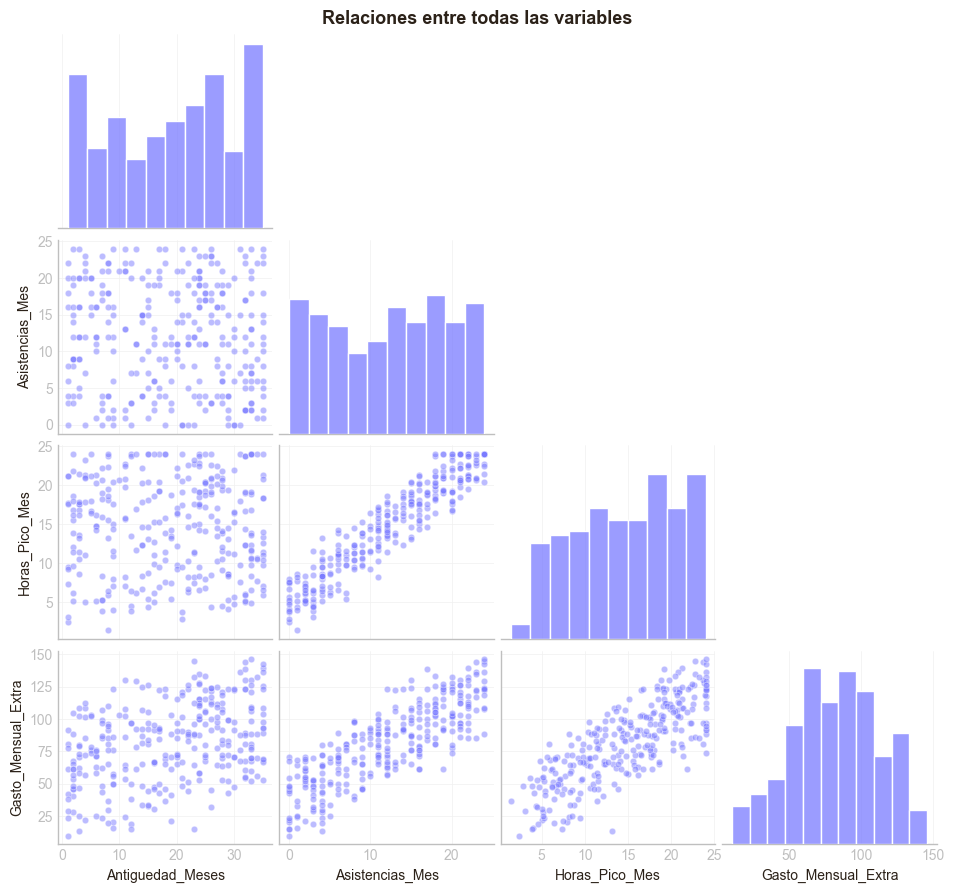

In [8]:
# Pair plot: relaciones por parejas
g = sns.pairplot(
    data[cols_num], height=2.2, aspect=1.1,
    plot_kws={'color': PURPLE, 'alpha': 0.5, 's': 22, 'edgecolor': 'white', 'linewidth': 0.5},
    diag_kws={'color': PURPLE, 'edgecolor': 'white'},
    corner=True
)
g.fig.suptitle('Relaciones entre todas las variables', y=1.01, fontsize=13, fontweight='bold', color=INK)
plt.show()

## 4. Train / Test Split
Excluimos `Abandono` para evitar Data Leakage. Un cliente que se ha dado de baja es, por definición, insatisfecho. Si la incluimos en el modelo, estaríamos haciendo trampas.

In [9]:
X = data[["Antiguedad_Meses", "Asistencias_Mes", "Horas_Pico_Mes", "Gasto_Mensual_Extra"]]
y = data["Satisfecho"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} registros ({y_train.mean():.1%} satisfechos)")
print(f"Test:  {X_test.shape[0]} registros ({y_test.mean():.1%} satisfechos)")

Train: 240 registros (47.9% satisfechos)
Test:  60 registros (48.3% satisfechos)


## 5. Selección de profundidad óptima con validación cruzada

La profundidad (`max_depth`) es el parámetro más importante de un árbol:
- **Muy poca** → underfitting (no captura la señal)
- **Demasiada** → overfitting (memoriza el ruido)

Evaluamos profundidades de 1 a 10 con validación cruzada 5-fold sobre el set de entrenamiento.

In [ ]:
depths = range(1, 11)
cv_train = []
cv_test_scores = []

for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    # CV score (proxy de test)
    cv_score = cross_val_score(tree, X_train, y_train, cv=5, scoring="accuracy").mean()
    cv_test_scores.append(cv_score)
    # Train score (para ver overfitting)
    tree.fit(X_train, y_train)
    cv_train.append(accuracy_score(y_train, tree.predict(X_train)))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(depths), cv_train, marker="s", label="Train accuracy", color=NEUTRAL_LINE, linewidth=2)
ax.plot(list(depths), cv_test_scores, marker="o", label="CV accuracy (5-fold)", color=PURPLE, linewidth=2)
ax.axvline(x=2, color=INK, linestyle="--", linewidth=2, label="Elegido: depth=2")
ax.set_xlabel("Profundidad del árbol (max_depth)", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("Curva de complejidad — ¿Cuánta profundidad necesitamos?", fontsize=13, fontweight="bold")
ax.set_xticks(list(depths))
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("Detalle por profundidad:")
for d, tr, cv in zip(depths, cv_train, cv_test_scores):
    gap = tr - cv
    marker = " ← elegido" if d == 2 else ""
    print(f"  depth={d:2d} | train={tr:.4f} | CV Accuracy={cv:.4f} | gap={gap:.4f}{marker}")

### Lectura de la curva de complejidad

- **depth=1** tiene la mejor CV accuracy (91,25%), pero solo usa 1 variable. Complicado para entender el problema.
- **depth=2** (90,00% CV) añade una segunda pregunta y mantiene la generalización intacta. Gap train-CV mínimo.
- A partir de **depth=4**, el train accuracy sube pero el CV se estanca o cae — overfitting clásico.

**Decisión:** `max_depth=2`. Añade interpretabilidad (segunda regla) con solo 1,25 pp de coste en accuracy. En producción, la diferencia entre 91,25% y 90,00% es despreciable; la segunda regla aporta contexto operativo valioso.

## 6. Modelo final - Árbol de Decisión (depth=2)

In [11]:
tree = DecisionTreeClassifier(max_depth=2, random_state=42)
tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)
y_proba = tree.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("Árbol de Decisión (depth=2) — Métricas de evaluación")
print(f"Accuracy:  {acc:.1%}")
print(f"Recall:    {rec:.1%}")
print(f"AUC-ROC:   {auc:.3f}")
print()
print(classification_report(y_test, y_pred, target_names=["No Satisfecho", "Satisfecho"]))

Árbol de Decisión (depth=2) — Métricas de evaluación
Accuracy:  90.0%
Recall:    89.7%
AUC-ROC:   0.909

               precision    recall  f1-score   support

No Satisfecho       0.90      0.90      0.90        31
   Satisfecho       0.90      0.90      0.90        29

     accuracy                           0.90        60
    macro avg       0.90      0.90      0.90        60
 weighted avg       0.90      0.90      0.90        60



In [ ]:
#Matriz de confusión

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap=SEQUENTIAL_GREEN,
            linewidths=2, linecolor=BACKGROUND,
            xticklabels=["No Satisfecho", "Satisfecho"],
            yticklabels=["No Satisfecho", "Satisfecho"], ax=ax,
            annot_kws={"size": 12, "weight": "bold"})
color_annotations(ax, cm, threshold=cm.max() * 0.6)
ax.set_title("Matriz de confusión — Árbol de Decisión (depth=2)", fontsize=13, fontweight="bold", color=INK)
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

print(f"Errores: {(cm[0,1] + cm[1,0])} de {cm.sum()} predicciones")

## 7. Visualización del árbol

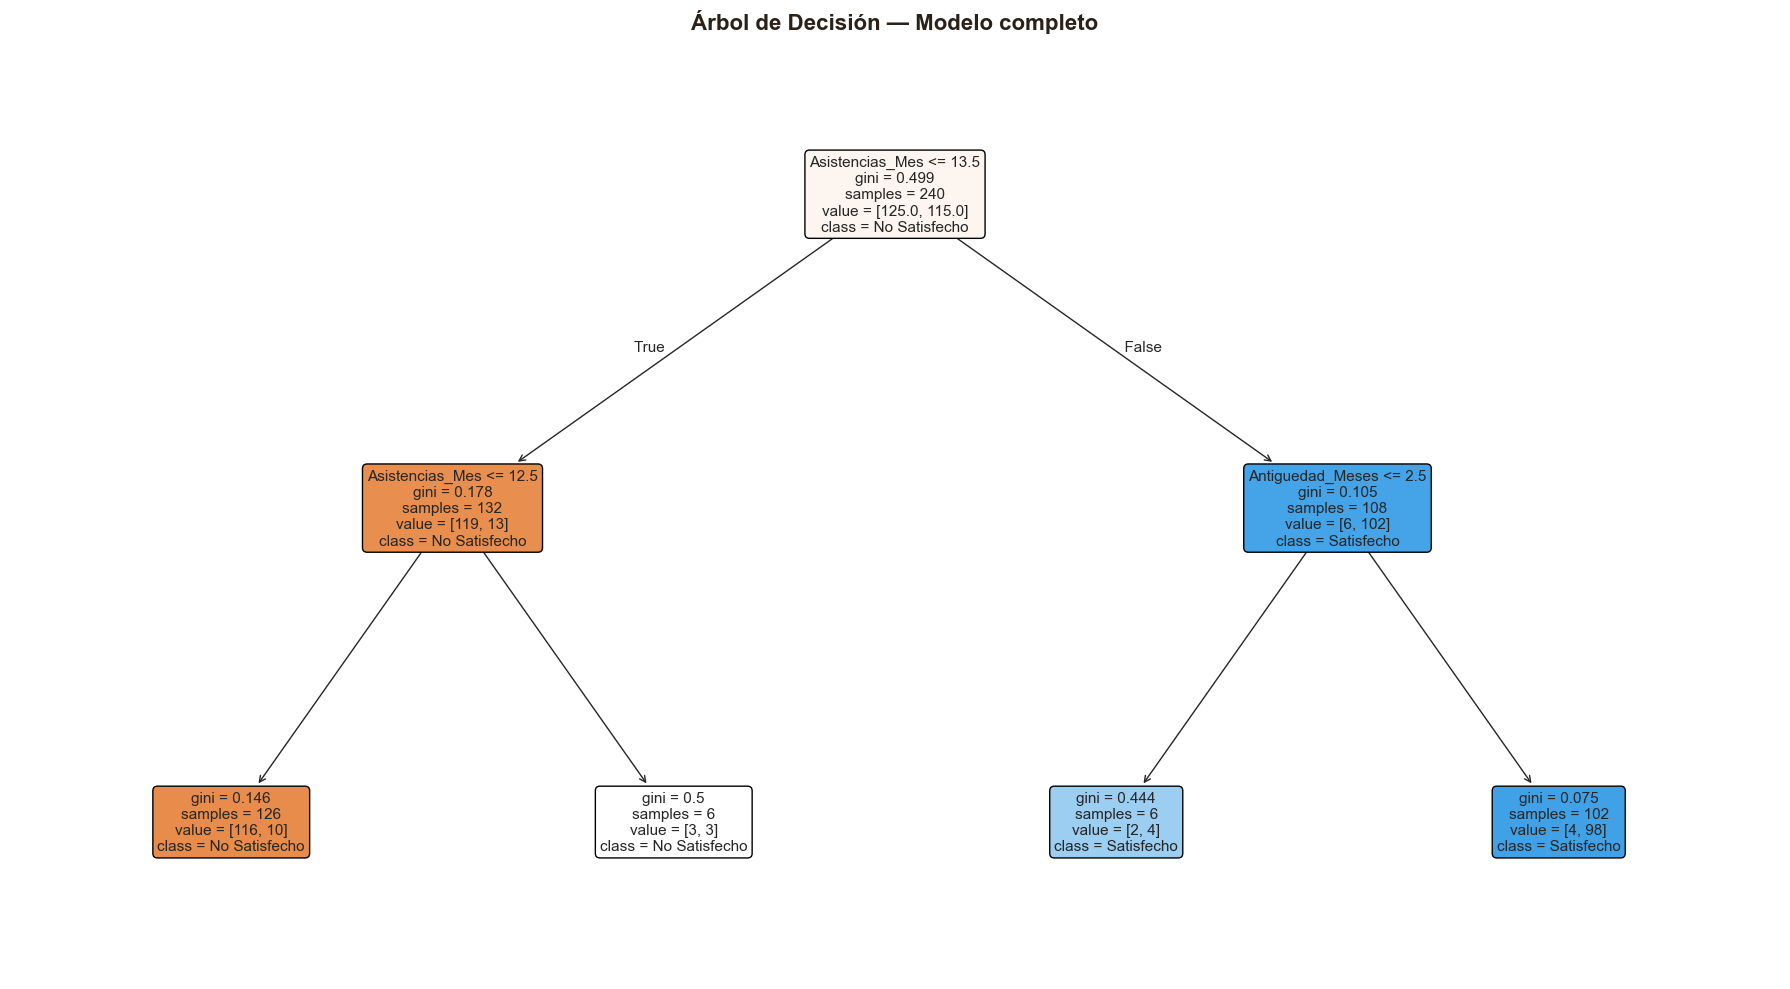

In [13]:
fig, ax = plt.subplots(figsize=(18, 10))
plot_tree(
    tree,
    feature_names=X.columns.tolist(),
    class_names=["No Satisfecho", "Satisfecho"],
    filled=True,
    rounded=True,
    fontsize=11,
    ax=ax,
)
ax.set_title("Árbol de Decisión — Modelo completo", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

### Lectura del Árbol de Decisión

El árbol de decisión utiliza **dos variables** para clasificar la satisfacción de los clientes: **Asistencias_Mes** y **Antiguedad_Meses**.

La primera decisión del modelo se basa en el número de **asistencias mensuales**, lo que indica que esta es la variable con mayor capacidad para diferenciar entre clientes satisfechos y no satisfechos.

### Reglas de decisión

- **Si un cliente asiste 13,5 veces al mes o menos**, el modelo lo clasifica mayoritariamente como **No Satisfecho**.
  - Si además asiste **12,5 veces o menos**, prácticamente todos los clientes pertenecen a la categoría **No Satisfecho** (116 de 126 casos).
  - El pequeño grupo que asiste entre **12,5 y 13,5 veces** presenta un comportamiento más equilibrado (3 satisfechos y 3 no satisfechos), por lo que el modelo muestra una mayor incertidumbre en esta zona.

- **Si un cliente asiste más de 13,5 veces al mes**, el modelo pasa a evaluar la **antigüedad**.
  - Los clientes con una antigüedad **superior a 2,5 meses** son clasificados casi siempre como **Satisfechos** (98 de 102 casos).
  - Los clientes con una antigüedad **igual o inferior a 2,5 meses** presentan un comportamiento menos definido (4 satisfechos y 2 no satisfechos), por lo que el modelo tiene menor confianza en esta clasificación.

### Conclusión

El árbol muestra que la **frecuencia de asistencia** es el principal factor para explicar la satisfacción de los clientes. Aquellos que acuden al gimnasio con mayor regularidad tienen una probabilidad mucho mayor de estar satisfechos.

Una vez superado ese nivel de asistencia, la **antigüedad** ayuda a refinar la predicción. Los clientes que llevan más tiempo en el gimnasio y mantienen una alta frecuencia de uso son los que presentan los niveles de satisfacción más elevados.

Desde el punto de vista del negocio, el modelo sugiere que **incrementar la frecuencia de asistencia durante los primeros meses** puede ser una estrategia eficaz para mejorar la satisfacción y reducir el riesgo de abandono de nuevos clientes.

In [14]:
#Reglas del árbol

rules = export_text(tree, feature_names=list(X.columns))
print("Reglas del árbol en formato texto:")
print(rules)

Reglas del árbol en formato texto:
|--- Asistencias_Mes <= 13.50
|   |--- Asistencias_Mes <= 12.50
|   |   |--- class: 0
|   |--- Asistencias_Mes >  12.50
|   |   |--- class: 0
|--- Asistencias_Mes >  13.50
|   |--- Antiguedad_Meses <= 2.50
|   |   |--- class: 1
|   |--- Antiguedad_Meses >  2.50
|   |   |--- class: 1



## 8. Importancia de variables

¿Cuánto contribuye cada variable a las decisiones del árbol?

In [ ]:
imp = pd.DataFrame({
    "feature": X.columns,
    "importance": tree.feature_importances_
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
top_feature = imp["importance"].idxmax()
colors = [PURPLE if i == top_feature else NEUTRAL_BAR for i in imp.index]
bars = ax.barh(imp["feature"], imp["importance"], color=colors)
for bar, v, i in zip(bars, imp["importance"], imp.index):
    is_top = i == top_feature
    ax.text(v + 0.005, bar.get_y() + bar.get_height()/2, f"{v:.1%}",
            va="center", fontsize=11, color=INK, fontweight="bold" if is_top else "normal")
ax.set_title("Importancia de variables — Árbol de Decisión (depth=2)", fontsize=13, fontweight="bold")
ax.set_xlabel("Importancia relativa (Gini)")
plt.tight_layout()
plt.show()

print("Ranking de importancia:")
for _, row in imp.sort_values("importance", ascending=False).iterrows():
    print(f"  {row['feature']:25s} {row['importance']:.1%}")

**Hallazgo clave:** `Asistencias_Mes` concentra el **98,9%** de la importancia del modelo. `Antiguedad_Meses` aporta un 1,1% (la segunda pregunta del árbol). `Horas_Pico_Mes` y `Gasto_Mensual_Extra` no aparecen en el modelo — con solo 2 niveles de profundidad, el árbol no las necesita.

Esto no significa que sean inútiles — significa que `Asistencias_Mes` absorbe toda la señal que necesita un modelo de 2 reglas.

## 9.Insights de negocio y recomendaciones

### El hallazgo

> La **frecuencia de asistencia al gimnasio** es, con diferencia, el principal factor que explica la satisfacción de los clientes. De hecho, el modelo asigna un **98,9% de la importancia** a esta variable, mientras que la antigüedad apenas aporta un **1,1%** para refinar algunos casos. Con únicamente dos reglas de decisión, el árbol consigue clasificar correctamente la gran mayoría de los clientes.

### Recomendaciones

**1. Sistema de alerta temprana**

Los clientes que registren **13 asistencias o menos al mes** deberían incorporarse automáticamente a un programa de seguimiento o retención. Esta regla puede implementarse fácilmente mediante un filtro en el CRM, sin necesidad de desplegar un modelo de Machine Learning en producción.

**2. Incrementar la frecuencia de uso**

La prioridad del negocio debe ser conseguir que los clientes superen las **13-14 asistencias mensuales**, ya que este es el punto a partir del cual el modelo comienza a clasificarlos mayoritariamente como satisfechos. Acciones como retos de asistencia, entrenamientos personalizados o incentivos por visitas pueden ayudar a alcanzar este objetivo.

**3. Reforzar el onboarding de nuevos clientes**

Una vez que el cliente asiste con frecuencia al gimnasio, la **antigüedad** ayuda a consolidar la satisfacción. Durante los primeros meses conviene realizar un seguimiento más cercano para fomentar el hábito de asistencia y acelerar la adaptación al gimnasio.

**4. Utilizar la asistencia como KPI operativo**

El porcentaje de clientes que realizan **más de 13 asistencias al mes** puede utilizarse como un indicador adelantado de satisfacción. Es un KPI objetivo, disponible en tiempo real y mucho más económico que depender exclusivamente de encuestas periódicas.
